In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import colorcet

import graph_tool.all as gt
from graph_tool import draw
import networkx as nx

import pymcm

%load_ext autoreload
%autoreload 2

In [2]:
labels = np.array(['a','a','a','b','b','b','b','b','c','c','d','d','e','e','e'])
matrix = np.array([
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0], # a
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0], # a
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # a
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # b
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # b
    [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # b
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # b
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # b
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # c
    [0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1], # c
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # d
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # d
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # e
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], # e
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]  # e
#    a  a  a  b  b  b  b  b  c  c  d  d  e  e  e
])
mask = np.invert(pymcm.array.grouped_diagonal_mask(labels))

In [3]:
unique, labels_num, counts = np.unique(labels, return_counts=True, return_inverse=True)

In [4]:
sums, net_labels = pymcm.array.matrix_grouped_stat(matrix, labels)
degree_in = sums.sum(axis=0, keepdims=True)
degree_out = sums.sum(axis=1, keepdims=True)
bidir = sums + sums.T
norm_mixed = degree_out + degree_in - sums

In [5]:
print(sums)
print(degree_in)
print(degree_out)

[[0. 2. 1. 0. 1.]
 [5. 0. 0. 0. 0.]
 [1. 3. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [2. 1. 0. 1. 0.]]
[[9. 6. 1. 1. 2.]]
[[4.]
 [5.]
 [5.]
 [1.]
 [4.]]


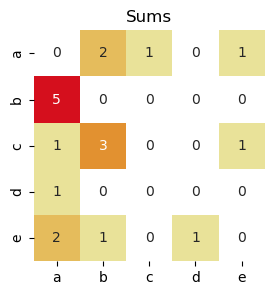

In [6]:
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(sums, square=True, cmap=colorcet.m_CET_L18, annot=True, cbar=False, ax=ax)
ax.set(xticklabels=unique, yticklabels=unique, title='Sums');

# 1. Normalize by degree out

In [7]:
wrt_outputs = sums / degree_out
wrt_outputs[np.isnan(wrt_outputs)] = 0

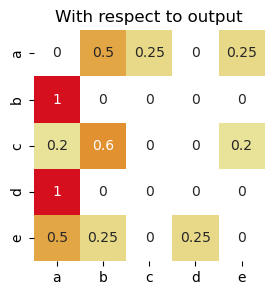

In [8]:
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(wrt_outputs, square=True, cmap=colorcet.m_CET_L18, annot=True, cbar=False, ax=ax)
ax.set(xticklabels=unique, yticklabels=unique, title='With respect to output');

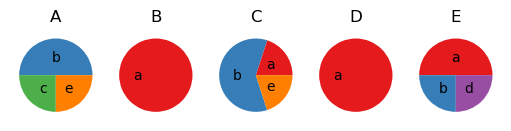

In [9]:
colours = np.array(colormaps['Set1'].colors[:5])
fig, axs = plt.subplots(1,5, figsize=(5,2), layout="constrained")

for row, label, ax in zip(wrt_outputs, unique, axs):

    to_plot = row[row != 0]
    to_label = unique[row != 0]
    to_colour = colours[row != 0]

    patches, text_labels = ax.pie(to_plot, labels=to_label, 
            rotatelabels=False,
            labeldistance=0.5,
            startangle=0,
            colors=to_colour,
            radius=1,
            textprops={'va': 'center', 'ha': 'center'}
            )
    
    ax.set_title(label.upper())

# 2. Normalize by degree in

In [10]:
wrt_inputs = sums / degree_in
wrt_inputs[np.isnan(wrt_inputs)] = 0

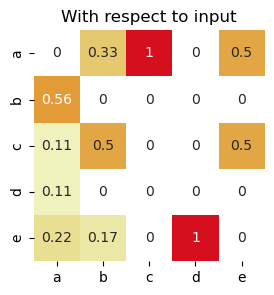

In [11]:
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(wrt_inputs, square=True, cmap=colorcet.m_CET_L18, annot=True, cbar=False, ax=ax)
ax.set(xticklabels=unique, yticklabels=unique, title='With respect to input');

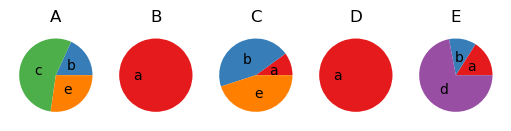

In [12]:
colours = np.array(colormaps['Set1'].colors[:5])
fig, axs = plt.subplots(1,5, figsize=(5,2), layout="constrained")

for row, label, ax in zip(wrt_inputs, unique, axs):

    to_plot = row[row != 0]
    to_label = unique[row != 0]
    to_colour = colours[row != 0]

    patches, text_labels = ax.pie(to_plot, labels=to_label, 
            rotatelabels=False,
            labeldistance=0.5,
            startangle=0,
            colors=to_colour,
            radius=1,
            textprops={'va': 'center', 'ha': 'center'}
            )
    
    ax.set_title(label.upper())

# 3. Normalize by reciprocal connections

In [13]:
wrt_reciprocal = sums / (sums + sums.T)
wrt_reciprocal[np.isnan(wrt_reciprocal)] = 0

/tmp/ipykernel_3050391/3966007853.py:1: RuntimeWarning: invalid value encountered in divide
  wrt_reciprocal = sums / (sums + sums.T)


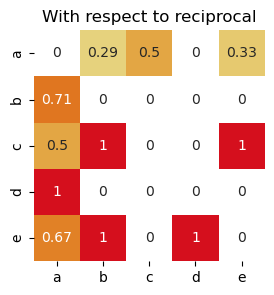

In [14]:
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(wrt_reciprocal, square=True, cmap=colorcet.m_CET_L18, annot=True, cbar=False, ax=ax)
ax.set(xticklabels=unique, yticklabels=unique, title='With respect to reciprocal');

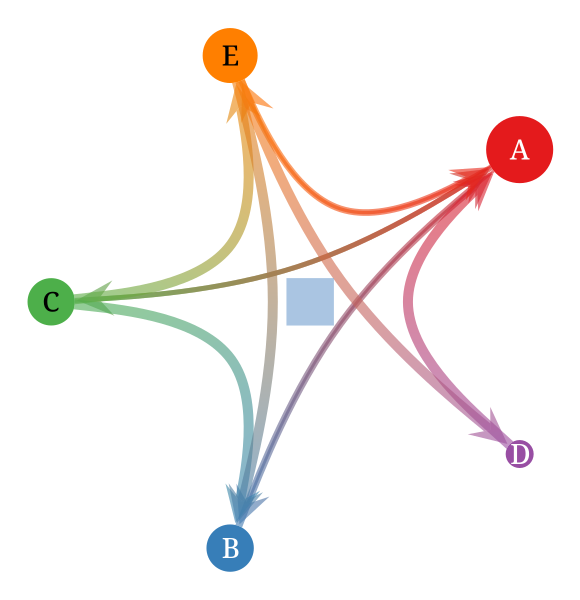

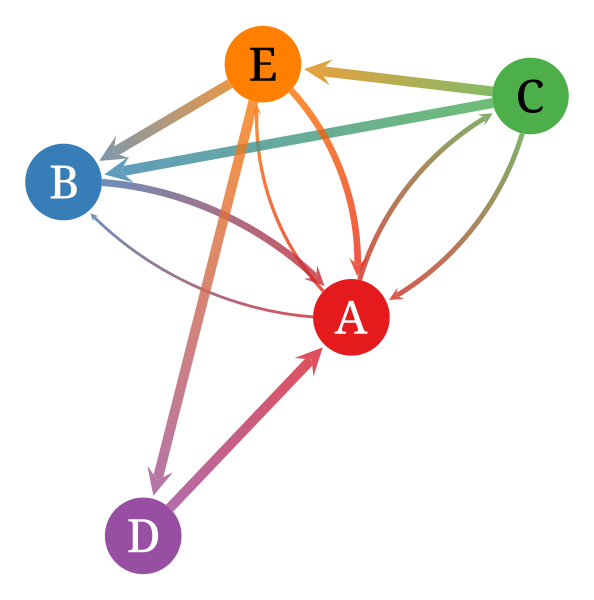

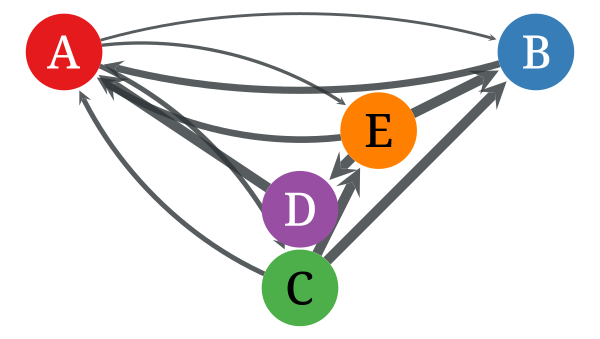

In [66]:
colours = np.array(colormaps['Set1'].colors[:5])

G = gt.Graph(directed=True)
vertices = list(G.add_vertex(n=5))
for i, j in zip(*wrt_reciprocal.nonzero()):
    G.add_edge(vertices[i], vertices[j])

vertex_colours = G.new_vertex_property(value_type='string', vals=list(map(pymcm.functions.rgb2hex, np.array(colours) * 255)))
weights = G.new_edge_property(value_type='double', vals=wrt_reciprocal[wrt_reciprocal.nonzero()]*5)
vertex_names = G.new_vertex_property(value_type='string', vals=map(str.upper, unique))

state = gt.minimize_nested_blockmodel_dl(G)
state.draw( 
    bg_color='white', 
    vertex_text=vertex_names, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0,0,0,0], 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(300,300), 
);

state = gt.minimize_blockmodel_dl(G)
state.draw(
    bg_color='white', 
    vertex_text=vertex_names, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0,0,0,0], 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(300,300), 
);

# pos = gt.arf_layout(G, max_iter=0, a=5, d=5)
pos = gt.planar_layout(G)
gt.graph_draw(
    G,
    pos=pos,
    bg_color='white', 
    vertex_text=vertex_names, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0,0,0,0], 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(300,300), 
);

# 4. Normalize by mix of afferent and efferent

In [16]:
wrt_mixed = sums / (degree_out + degree_in - sums)
wrt_mixed[np.isnan(wrt_mixed)] = 0

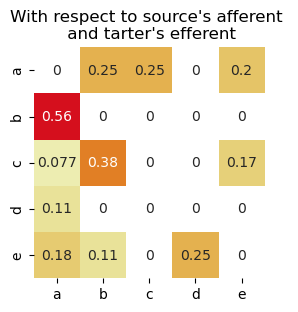

In [17]:
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(wrt_mixed, square=True, cmap=colorcet.m_CET_L18, annot=True, cbar=False, ax=ax)
ax.set(xticklabels=unique, yticklabels=unique, title="With respect to source's afferent \n and target's efferent");

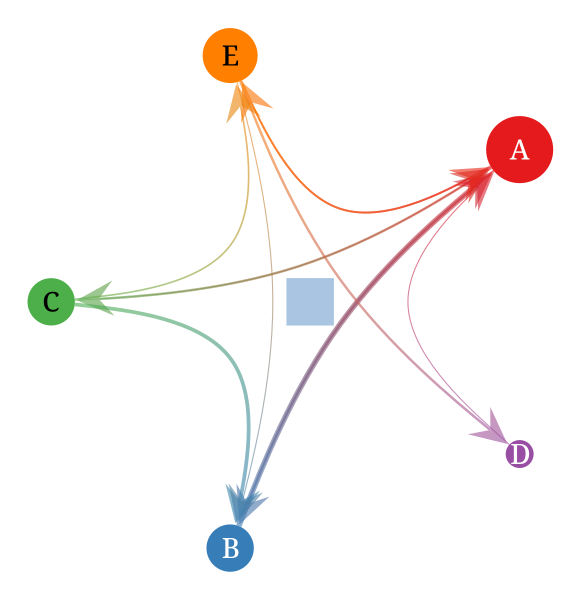

In [18]:
colours = np.array(colormaps['Set1'].colors[:5])

G = gt.Graph(directed=True)
vertices = list(G.add_vertex(n=5))
for i, j in zip(*wrt_mixed.nonzero()):
    G.add_edge(vertices[i], vertices[j])

vertex_colours = G.new_vertex_property(value_type='string', vals=list(map(pymcm.functions.rgb2hex, np.array(colours) * 255)))
weights = G.new_edge_property(value_type='double', vals=wrt_mixed[wrt_mixed.nonzero()]*5)
vertex_names = G.new_vertex_property(value_type='string', vals=map(str.upper, unique))

state = gt.minimize_nested_blockmodel_dl(G)
gt.draw_hierarchy(
    state, 
    bg_color='white', 
    vertex_text=vertex_names, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0,0,0,0], 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(300,300), 
);

---

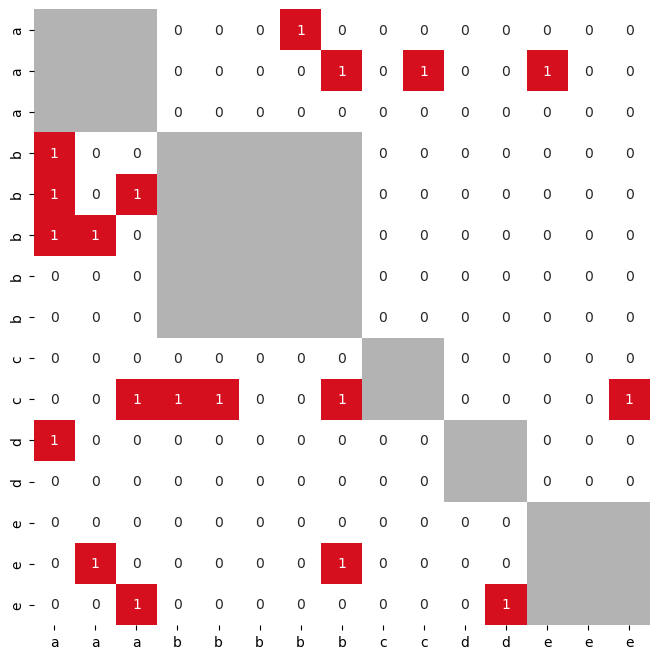

In [19]:
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(matrix, square=True, cmap=colorcet.m_CET_L18, annot=True, cbar=False, ax=ax, mask=np.invert(mask))
ax.set(xticklabels=labels, yticklabels=labels)
ax.set_facecolor('.7')

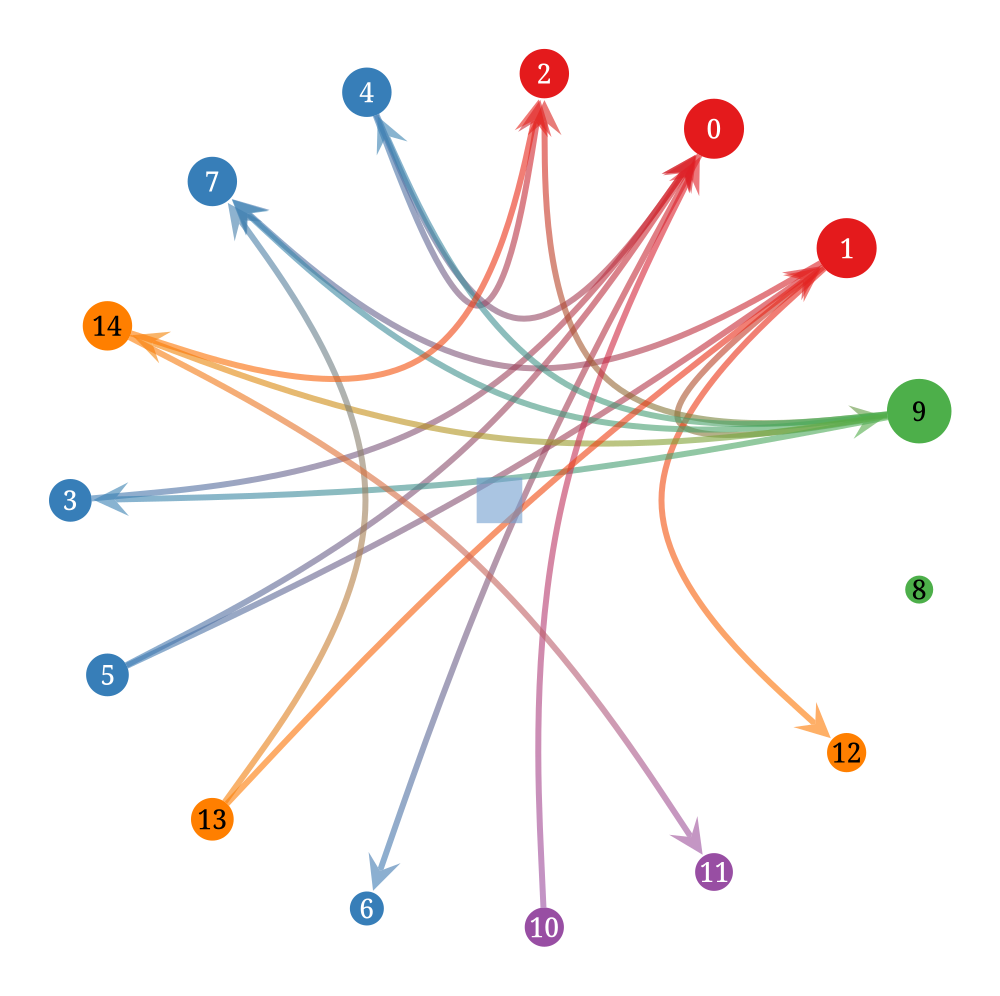

(<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fbae29f48c0, at 0x7fbacaa87b60>,
 <GraphView object, directed, with 16 vertices and 15 edges, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x7fbae27b3f20, at 0x7fbaca8755b0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x7fbae27b3f20, at 0x7fbacaa70770>, False), at 0x7fbae27b3f20>,
 <VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fbae27b3f20, at 0x7fbaca876f60>)

In [20]:
cmap = colormaps['Set1']
G = gt.Graph(directed=True)

vertices = list(G.add_vertex(n=15))
for i, j in zip(*matrix.nonzero()):
    G.add_edge(vertices[i], vertices[j])

colours = [pymcm.functions.rgb2hex(np.array(cmap.colors[idx]) * 255) for idx in labels_num]
vertex_colours = G.new_vertex_property(value_type='string', vals=colours)
weights = G.new_edge_property(value_type='int', val=3)

# radius = 20
# alpha = np.radians(12) # space betwee nthe nodes, radians
# beta = (2*np.pi - (alpha * (counts-1)).sum()) / 5 # space between the nets, radians

# thetas = [0]
# for count in counts:
#     thetas.extend(alpha * np.ones(count-1))
#     thetas.extend([beta])

# xs = radius * np.cos(np.cumsum(thetas))
# ys = radius * np.sin(np.cumsum(thetas))

# xy = list(zip(xs, ys))
# pos = G.new_vertex_property(value_type='vector<float>', vals=xy)

# draw.graph_draw(G, pos=pos,
#     vertex_text=G.vertex_index,
#     vertex_fill_color=vertex_colours,
#     edge_pen_width=weights,
#     vertex_color=[0,0,0,0],
#     bg_color='white', ink_scale=1,
#     output_size=(500,500))

state = gt.minimize_nested_blockmodel_dl(G)
gt.draw_hierarchy(
    state, 
    bg_color='white', 
    vertex_text=G.vertex_index, 
    vertex_fill_color=vertex_colours, 
    vertex_color=[0,0,0,0], 
    ink_scale=1,
    edge_pen_width=weights,
    output_size=(500,500), 
);


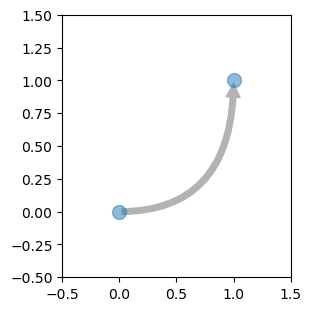

In [21]:
from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(layout='constrained', figsize=(3,3))

x1, y1 = 0, 0
x2, y2 = 1, 1

ax.plot([x1, x2], [y1, y2], ".", markersize=20, alpha=0.5)
ax.set(xlim=[-0.5, 1.5], ylim=[-0.5, 1.5])
arrow = FancyArrowPatch(
    (x1, y1),
    (x2, y2),
    mutation_scale=20,
    connectionstyle='angle3,angleA=0,angleB=90',
    # alpha=0.7,
    # facecolor='gray',
    # edgecolor='white',
    color='.7',
    linewidth=1,
    fill=True,
    label='130'
)
ax.add_patch(arrow)